# Knowledge Tracing Model Comparison on the Riiid Dataset

This notebook develops and evaluates Bayesian Knowledge Tracing (BKT), Deep Knowledge Tracing (DKT), and Self-Attentive Knowledge Tracing (SAKT) on a reproducible sample of the Riiid Answer Correctness Prediction dataset. Models are compared using student-level data separation, discrimination, accuracy, calibration, sequence-length sensitivity, skill sparsity, and learner-history analyses.


In [1]:
import gc
import itertools
import os
import random
import shutil
import sys
import warnings
from importlib.metadata import version
from pathlib import Path
from zipfile import ZipFile

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
import sklearn
import tensorflow as tf
from kaggle.api.kaggle_api_extended import KaggleApi
from pyBKT.fit import E_step
from pyBKT.models import Model as BKTModel
from sklearn.calibration import calibration_curve
from sklearn.metrics import accuracy_score, brier_score_loss, roc_auc_score, roc_curve
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import (
    Add,
    Dense,
    Dropout,
    Embedding,
    Input,
    Layer,
    LayerNormalization,
    LSTM,
    MultiHeadAttention,
)
from tensorflow.keras.models import Model as KerasModel
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [2]:
warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
TARGET_STUDENTS = 20_000

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

expected_versions = {
    "numpy": "1.26.4",
    "pandas": "2.2.3",
    "scipy": "1.13.1",
    "scikit-learn": "1.6.1",
    "pyBKT": "1.4.2",
}

installed_versions = {
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scipy": scipy.__version__,
    "scikit-learn": sklearn.__version__,
    "pyBKT": version("pyBKT"),
    "tensorflow": tf.__version__,
}

incorrect_versions = {
    package: (expected, installed_versions[package])
    for package, expected in expected_versions.items()
    if installed_versions[package] != expected
}

if incorrect_versions:
    raise RuntimeError(f"Unexpected package versions: {incorrect_versions}")

if Path(E_step.__file__).suffix != ".so":
    raise RuntimeError("The compiled pyBKT backend is required.")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR = RESULTS_DIR / "tables"
PREDICTIONS_DIR = RESULTS_DIR / "predictions"
MODELS_DIR = PROJECT_ROOT / "models"

for directory in (
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    FIGURES_DIR,
    TABLES_DIR,
    PREDICTIONS_DIR,
    MODELS_DIR,
):
    directory.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = RAW_DATA_DIR / "train.csv"
QUESTIONS_PATH = RAW_DATA_DIR / "questions.csv"

print("Environment validated and project directories configured.")
print("pyBKT backend:", Path(E_step.__file__).name)


Environment validated and project directories configured.
pyBKT backend: E_step.cpython-312-darwin.so


## Data Access

The competition files are downloaded only when they are absent from `data/raw`. Kaggle credentials must be stored in `~/.kaggle/kaggle.json` or downloaded to the user's Downloads directory.


In [3]:
downloaded_kaggle_json = Path.home() / "Downloads" / "kaggle.json"
kaggle_directory = Path.home() / ".kaggle"
kaggle_json_path = kaggle_directory / "kaggle.json"

kaggle_directory.mkdir(exist_ok=True)

if downloaded_kaggle_json.exists() and not kaggle_json_path.exists():
    shutil.copy2(downloaded_kaggle_json, kaggle_json_path)

if not kaggle_json_path.exists():
    raise FileNotFoundError(
        "Download kaggle.json from Kaggle Settings and rerun this cell."
    )

os.chmod(kaggle_json_path, 0o600)

print("Kaggle API credentials configured.")


Kaggle API credentials configured.


In [4]:
if not TRAIN_PATH.exists() or not QUESTIONS_PATH.exists():
    api = KaggleApi()
    api.authenticate()

    api.competition_download_files(
        "riiid-test-answer-prediction",
        path=RAW_DATA_DIR,
        quiet=False,
    )

    archive_path = RAW_DATA_DIR / "riiid-test-answer-prediction.zip"

    if not archive_path.exists():
        raise FileNotFoundError("The Kaggle archive was not downloaded.")

    with ZipFile(archive_path, "r") as archive:
        archive.extractall(RAW_DATA_DIR)

print(f"Raw data available in: {RAW_DATA_DIR}")


Raw data available in: /Users/tolulopesoetan/Desktop/msc_kt_ednet/data/raw


In [5]:
required_files = {
    "training interactions": TRAIN_PATH,
    "question metadata": QUESTIONS_PATH,
}

missing_files = {
    name: path
    for name, path in required_files.items()
    if not path.exists()
}

if missing_files:
    for name, path in missing_files.items():
        print(f"Missing {name}: {path}")

    raise FileNotFoundError(
        "Required Riiid files are missing from data/raw."
    )

print("Environment and data paths configured.")


Environment and data paths configured.


## Data Preparation


In [6]:
print("Scanning unique students.")

all_users = (
    pd.read_csv(TRAIN_PATH, usecols=["user_id"])
    .squeeze("columns")
    .unique()
)

rng = np.random.default_rng(SEED)

sampled_users = rng.choice(
    all_users,
    size=TARGET_STUDENTS,
    replace=False,
)

print(f"Successfully sampled {len(sampled_users):,} students.")


Scanning unique students.
Successfully sampled 20,000 students.


In [7]:
print("Extracting interactions for the selected students.")

columns_to_load = [
    "user_id",
    "content_id",
    "answered_correctly",
    "content_type_id",
    "timestamp",
]

filtered_chunks = []

for chunk in pd.read_csv(
    TRAIN_PATH,
    usecols=columns_to_load,
    chunksize=1_000_000,
):
    filtered_chunk = chunk[
        (chunk["content_type_id"] == 0)
        & (chunk["user_id"].isin(sampled_users))
    ]

    filtered_chunks.append(filtered_chunk)

final_df = pd.concat(filtered_chunks, ignore_index=True)
final_df = final_df.drop(columns=["content_type_id"])

del filtered_chunks, all_users
gc.collect()

print(f"Total interactions loaded: {len(final_df):,}")


Extracting interactions for the selected students.
Total interactions loaded: 5,033,866


In [8]:
questions_raw = pd.read_csv(
    QUESTIONS_PATH,
    usecols=["question_id", "tags", "part"],
)

questions_raw["tags"] = questions_raw["tags"].fillna("-1")
questions_raw["tag_list"] = (
    questions_raw["tags"]
    .astype(str)
    .str.split(" ")
)

exploded_tags = questions_raw.explode("tag_list")
exploded_tags = exploded_tags[
    exploded_tags["tag_list"] != "-1"
]

exploded_tags["tag_list"] = (
    exploded_tags["tag_list"].astype(int)
)

unique_tags = exploded_tags["tag_list"].nunique()

questions_raw["tag_count"] = (
    questions_raw["tag_list"].apply(len)
)

print(f"Unique skill tags in Riiid questions.csv: {unique_tags}")
print()
print("Tags per question:")
print(
    questions_raw["tag_count"]
    .value_counts()
    .sort_index()
    .to_string()
)


Unique skill tags in Riiid questions.csv: 188

Tags per question:
tag_count
1    6561
2     171
3    3976
4    2021
5     686
6     108


In [9]:
questions_df = questions_raw[
    ["question_id", "part", "tags"]
].copy()

questions_df["tag_1"] = (
    questions_df["tags"]
    .astype(str)
    .str.split(" ")
    .str[0]
)

questions_df = questions_df.drop(columns=["tags"])

print("Question metadata prepared.")


Question metadata prepared.


In [10]:
print("Merging skill metadata into student interactions.")

final_df = final_df.merge(
    questions_df,
    left_on="content_id",
    right_on="question_id",
    how="left",
)

final_df = final_df.drop(columns=["question_id"])

del questions_df, questions_raw, exploded_tags
gc.collect()

print("Metadata merge complete.")


Merging skill metadata into student interactions.
Metadata merge complete.


In [11]:
print("Sorting student sequences chronologically.")

final_df = final_df.sort_values(
    by=["user_id", "timestamp"]
).reset_index(drop=True)

label_encoder = LabelEncoder()

final_df["skill"] = label_encoder.fit_transform(
    final_df["tag_1"]
)

num_skills = final_df["skill"].nunique()

print(f"Total unique skills to model: {num_skills}")


Sorting student sequences chronologically.
Total unique skills to model: 117


In [12]:
print("\n--- Pipeline Data Summary ---")
print(f"Total Students: {final_df['user_id'].nunique():,}")
print(f"Total Valid Interactions: {len(final_df):,}")
print(
    "Max Sequence Length Found:",
    final_df.groupby("user_id").size().max(),
)
print(f"Total Distinct Skills (tag_1): {num_skills}")
print("\nPreview:")

display(final_df.head())



--- Pipeline Data Summary ---
Total Students: 20,000
Total Valid Interactions: 5,033,866
Max Sequence Length Found: 14855
Total Distinct Skills (tag_1): 117

Preview:


,timestamp,user_id,content_id,answered_correctly,part,tag_1,skill
0,0,115,5692,1,5,151,31
1,56943,115,5716,1,5,168,42
2,118363,115,128,1,1,131,18
3,131167,115,7860,1,1,131,18
4,137965,115,7922,1,1,131,18


## Student-Level Train/Test Split


In [13]:
print("Splitting data by student.")

group_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=SEED,
)

train_idx, test_idx = next(
    group_split.split(
        final_df,
        groups=final_df["user_id"],
    )
)

train_df = final_df.iloc[train_idx].copy()
test_df = final_df.iloc[test_idx].copy()

print(f"Training students: {train_df['user_id'].nunique():,}")
print(f"Testing students: {test_df['user_id'].nunique():,}")


Splitting data by student.
Training students: 16,000
Testing students: 4,000


## Bayesian Knowledge Tracing Baseline


In [14]:
bkt_train = train_df[
    ["user_id", "tag_1", "answered_correctly"]
].rename(
    columns={
        "tag_1": "skill_name",
        "answered_correctly": "correct",
    }
)

bkt_model = BKTModel(seed=SEED)

print("Training BKT baseline model.")
bkt_model.fit(data=bkt_train)
print("BKT training complete.")


Training BKT baseline model.
BKT training complete.


In [15]:
bkt_test = test_df[
    ["user_id", "tag_1", "answered_correctly"]
].rename(
    columns={
        "tag_1": "skill_name",
        "answered_correctly": "correct",
    }
)

print("Predicting with BKT on the test set.")

bkt_preds = bkt_model.predict(data=bkt_test)

missing_predictions = (
    bkt_preds["correct_predictions"].isna().sum()
)

if missing_predictions:
    raise RuntimeError(
        f"BKT produced {missing_predictions:,} missing predictions."
    )

bkt_auc = roc_auc_score(
    bkt_preds["correct"],
    bkt_preds["correct_predictions"],
)

print(f"BKT Test AUC: {bkt_auc:.4f}")


Predicting with BKT on the test set.
BKT Test AUC: 0.6300


## Deep Knowledge Tracing Baseline

Deep Knowledge Tracing is implemented using an LSTM network. Each interaction is represented by a combined skill-response token, and the model predicts the correctness of the learner's next response. Sequences are limited to the 100 most recent interactions.


In [16]:
MAX_SEQ_LEN = 100

def create_sequence_data(data, max_length):
    skills = []
    correctness = []
    users = []

    for user_id, user_data in data.groupby("user_id", sort=False):
        skill_sequence = user_data["skill"].to_numpy()
        response_sequence = user_data["answered_correctly"].to_numpy()

        if len(skill_sequence) < 2:
            continue

        skill_sequence = skill_sequence[-max_length:]
        response_sequence = response_sequence[-max_length:]

        skills.append(skill_sequence)
        correctness.append(response_sequence)
        users.append(user_id)

    return skills, correctness, users

print("Sequence extraction configured.")


Sequence extraction configured.


In [17]:
print("Building input and target sequences.")

sequence_skills, sequence_responses, sequence_users = create_sequence_data(
    final_df,
    MAX_SEQ_LEN,
)

input_sequences = []
target_sequences = []

for skill_sequence, response_sequence in zip(
    sequence_skills,
    sequence_responses,
):
    input_skills = skill_sequence[:-1]
    input_responses = response_sequence[:-1]

    interaction_tokens = (
        input_skills * 2
        + input_responses
        + 1
    )

    input_sequences.append(interaction_tokens)
    target_sequences.append(response_sequence[1:])

X = pad_sequences(
    input_sequences,
    maxlen=MAX_SEQ_LEN,
    padding="pre",
    value=0,
)

y = pad_sequences(
    target_sequences,
    maxlen=MAX_SEQ_LEN,
    padding="pre",
    value=-1,
)

print(f"X tensor shape: {X.shape}")
print(f"y tensor shape: {y.shape}")


Building input and target sequences.
X tensor shape: (19999, 100)
y tensor shape: (19999, 100)


In [18]:
sequence_users = np.asarray(sequence_users)

training_users = train_df["user_id"].unique()
testing_users = test_df["user_id"].unique()

train_mask = np.isin(sequence_users, training_users)
test_mask = np.isin(sequence_users, testing_users)

X_train = X[train_mask]
y_train = y[train_mask]

X_test = X[test_mask]
y_test = y[test_mask]

print(f"DKT training samples: {X_train.shape[0]:,}")
print(f"DKT testing samples: {X_test.shape[0]:,}")


DKT training samples: 15,999
DKT testing samples: 4,000


In [19]:
vocab_size = (num_skills * 2) + 1

inputs = Input(
    shape=(MAX_SEQ_LEN,),
    name="interaction_sequence",
)

embedded = Embedding(
    input_dim=vocab_size,
    output_dim=64,
    mask_zero=True,
    name="interaction_embedding",
)(inputs)

hidden_states = LSTM(
    units=64,
    return_sequences=True,
    name="knowledge_state",
)(embedded)

outputs = Dense(
    units=1,
    activation="sigmoid",
    name="correctness_probability",
)(hidden_states)

dkt_model = KerasModel(
    inputs=inputs,
    outputs=outputs,
    name="dkt_lstm",
)

dkt_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
)

dkt_model.summary()


Model: "dkt_lstm"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ interaction_sequen… │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ interaction_embedd… │ (None, 100, 64)   │     15,040 │ interaction_sequ… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 100)       │          0 │ interaction_sequ… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ knowledge_state     │ (None, 100, 64)   │     33,024 │ interaction_embe… │
│ (LSTM)              │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ correctness_probab… │ (None, 100, 1)    │         65 │ knowledge_state[… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 48,129 (188.00 KB)

 Trainable params: 48,129 (188.00 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
print(f"Initial y_train shape: {y_train.shape}")

if y_train.ndim == 2:
    y_train = np.expand_dims(y_train, axis=-1)
    y_test = np.expand_dims(y_test, axis=-1)

print(f"Updated y_train shape: {y_train.shape}")


Initial y_train shape: (15999, 100)
Updated y_train shape: (15999, 100, 1)


In [21]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=2,
    restore_best_weights=True,
)

print("Training DKT.")

dkt_history = dkt_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1,
)

print("Evaluating DKT.")

dkt_predictions = dkt_model.predict(
    X_test,
    verbose=0,
)

valid_sequence_mask = X_test != 0

y_test_clean = y_test[valid_sequence_mask].ravel()
dkt_predictions_clean = dkt_predictions[valid_sequence_mask].ravel()

dkt_auc = roc_auc_score(
    y_test_clean,
    dkt_predictions_clean,
)

print(f"BKT baseline AUC: {bkt_auc:.4f}")
print(f"DKT model AUC:    {dkt_auc:.4f}")


Training DKT.
Epoch 1/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 0.6445 - val_loss: 0.6404
Epoch 2/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.6393 - val_loss: 0.6390
Epoch 3/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.6378 - val_loss: 0.6378
Epoch 4/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.6366 - val_loss: 0.6370
Epoch 5/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.6356 - val_loss: 0.6365
Epoch 6/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.6348 - val_loss: 0.6359
Epoch 7/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.6341 - val_loss: 0.6356
Epoch 8/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.6336 - val_loss: 0.6353
Epoch 9/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.6331 - val_loss: 0.6350
Epoch 10/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.6327 - val_loss: 0.6349
Evaluating DKT.
BKT baseline AUC: 0.6300
DKT model AUC:    0.6593


## Initial Self-Attentive Knowledge Tracing Model

The first SAKT configuration uses an upper-triangular attention mask. Its evaluation is retained to diagnose the effect of allowing attention to future sequence positions before applying a strictly causal mask.


In [22]:
tf.keras.backend.clear_session()
del dkt_model
gc.collect()

print("DKT model memory released.")


DKT model memory released.


In [23]:
class UpperTriangularAttentionMask(Layer):
    def call(self, inputs):
        sequence_length = tf.shape(inputs)[1]
        batch_size = tf.shape(inputs)[0]

        mask = 1 - tf.linalg.band_part(
            tf.ones((sequence_length, sequence_length)),
            -1,
            0,
        )

        mask = tf.expand_dims(mask, axis=0)
        return tf.tile(mask, [batch_size, 1, 1])


class FeedForwardNetwork(Layer):
    def __init__(
        self,
        model_dimension,
        hidden_dimension,
        dropout_rate=0.1,
        **kwargs,
    ):
        super().__init__(**kwargs)

        self.hidden_layer = Dense(
            hidden_dimension,
            activation="relu",
        )
        self.output_layer = Dense(model_dimension)
        self.dropout = Dropout(dropout_rate)

    def call(self, inputs, training=False):
        x = self.hidden_layer(inputs)
        x = self.dropout(x, training=training)
        return self.output_layer(x)


def masked_binary_crossentropy(y_true, y_pred):
    valid_targets = tf.maximum(y_true, 0.0)

    loss = tf.keras.losses.binary_crossentropy(
        valid_targets,
        y_pred,
    )

    mask = tf.cast(
        tf.not_equal(y_true, -1.0),
        dtype=tf.float32,
    )
    mask = tf.squeeze(mask, axis=-1)

    return tf.reduce_sum(loss * mask) / (
        tf.reduce_sum(mask) + 1e-8
    )

print("SAKT components defined.")


SAKT components defined.


In [24]:
embedding_dimension = 64
attention_heads = 4
feedforward_dimension = 128

inputs = Input(
    shape=(MAX_SEQ_LEN,),
    name="interaction_inputs",
)

interaction_embedding = Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dimension,
    mask_zero=True,
    name="interaction_embedding",
)(inputs)

positions = tf.range(
    start=0,
    limit=MAX_SEQ_LEN,
    delta=1,
)

position_embedding = Embedding(
    input_dim=MAX_SEQ_LEN,
    output_dim=embedding_dimension,
    name="position_embedding",
)(positions)

x = interaction_embedding + position_embedding

attention_mask = UpperTriangularAttentionMask(
    name="attention_mask",
)(x)

attention_output = MultiHeadAttention(
    num_heads=attention_heads,
    key_dim=embedding_dimension,
    name="self_attention",
)(
    query=x,
    value=x,
    key=x,
    attention_mask=attention_mask,
)

x = Add()([x, attention_output])
x = LayerNormalization(epsilon=1e-6)(x)

feedforward_output = FeedForwardNetwork(
    model_dimension=embedding_dimension,
    hidden_dimension=feedforward_dimension,
)(x)

x = Add()([x, feedforward_output])
x = LayerNormalization(epsilon=1e-6)(x)

outputs = Dense(
    units=1,
    activation="sigmoid",
    name="correctness_probability",
)(x)

initial_sakt_model = KerasModel(
    inputs=inputs,
    outputs=outputs,
    name="initial_sakt",
)

initial_sakt_model.compile(
    optimizer="adam",
    loss=masked_binary_crossentropy,
)

initial_sakt_model.summary()


Model: "initial_sakt"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ interaction_inputs  │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ interaction_embedd… │ (None, 100, 64)   │     15,040 │ interaction_inpu… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 100, 64)   │          0 │ interaction_embe… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_mask      │ (None, 100, 100)  │          0 │ add[0][0]         │
│ (UpperTriangularAt… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ self_attention      │ (None, 100, 64)   │     66,368 │ attention_mask[0… │
│ (MultiHeadAttentio… │                   │            │ add[0][0],        │
│                     │                   │            │ add[0][0],        │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 100, 64)   │          0 │ add[0][0],        │
│                     │                   │            │ self_attention[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 100, 64)   │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feed_forward_netwo… │ (None, 100, 64)   │     16,576 │ layer_normalizat… │
│ (FeedForwardNetwor… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 100, 64)   │          0 │ layer_normalizat… │
│                     │                   │            │ feed_forward_net… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 100, 64)   │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ correctness_probab… │ (None, 100, 1)    │         65 │ layer_normalizat… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 98,305 (384.00 KB)

 Trainable params: 98,305 (384.00 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
early_stopping_sakt = EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=2,
    restore_best_weights=True,
)

print("Training the initial SAKT model.")

initial_sakt_history = initial_sakt_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stopping_sakt],
    verbose=1,
)

print("Evaluating the initial SAKT model.")

initial_sakt_predictions = initial_sakt_model.predict(
    X_test,
    verbose=0,
)

initial_sakt_predictions_clean = initial_sakt_predictions[
    valid_sequence_mask
].ravel()

initial_sakt_auc = roc_auc_score(
    y_test_clean,
    initial_sakt_predictions_clean,
)

print(f"Initial SAKT AUC: {initial_sakt_auc:.4f}")


Training the initial SAKT model.
Epoch 1/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 14s 55ms/step - loss: 0.5980 - val_loss: 0.5738
Epoch 2/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 13s 60ms/step - loss: 0.5606 - val_loss: 0.5444
Epoch 3/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step - loss: 0.5279 - val_loss: 0.5047
Epoch 4/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - loss: 0.4938 - val_loss: 0.4786
Epoch 5/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step - loss: 0.4693 - val_loss: 0.4596
Epoch 6/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - loss: 0.4476 - val_loss: 0.4378
Epoch 7/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - loss: 0.4279 - val_loss: 0.4176
Epoch 8/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - loss: 0.4088 - val_loss: 0.3967
Epoch 9/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - loss: 0.3915 - val_loss: 0.3830
Epoch 10/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 13s 59ms/step - loss: 0.3769 - val_loss: 0.3693
Evaluating the initial SAKT model.
Initial SAKT AUC: 0.8944


## Temporal Leakage Diagnosis and Causal SAKT Correction

Keras interprets `1` in an attention mask as permission to attend. The upper-triangular mask therefore exposes future interactions, including tokens containing the response subsequently used as the prediction target. The model is rebuilt with a lower-triangular causal mask combined with an explicit padding mask. Only the causal SAKT result is used in the primary model comparison.


In [26]:
tf.keras.backend.clear_session()
del initial_sakt_model
gc.collect()
tf.keras.utils.set_random_seed(SEED)

print(f"Initial SAKT AUC: {initial_sakt_auc:.4f}")


Initial SAKT AUC: 0.8944


In [27]:
class CausalPaddingMask(Layer):
    def call(self, interaction_tokens):
        sequence_length = tf.shape(interaction_tokens)[1]

        causal_mask = tf.linalg.band_part(
            tf.ones(
                (sequence_length, sequence_length),
                dtype=tf.bool,
            ),
            -1,
            0,
        )

        valid_keys = tf.not_equal(interaction_tokens, 0)
        valid_keys = tf.expand_dims(valid_keys, axis=1)

        return tf.logical_and(
            tf.expand_dims(causal_mask, axis=0),
            valid_keys,
        )


In [28]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

inputs = Input(
    shape=(MAX_SEQ_LEN,),
    name="interaction_inputs",
)

interaction_embedding = Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dimension,
    mask_zero=False,
    name="interaction_embedding",
)(inputs)

positions = tf.range(MAX_SEQ_LEN)

position_embedding = Embedding(
    input_dim=MAX_SEQ_LEN,
    output_dim=embedding_dimension,
    name="position_embedding",
)(positions)

x = interaction_embedding + position_embedding

attention_mask = CausalPaddingMask(
    name="causal_padding_mask",
)(inputs)

attention_output = MultiHeadAttention(
    num_heads=attention_heads,
    key_dim=embedding_dimension,
    name="causal_self_attention",
)(
    query=x,
    value=x,
    key=x,
    attention_mask=attention_mask,
)

x = Add(name="attention_residual")([x, attention_output])
x = LayerNormalization(
    epsilon=1e-6,
    name="attention_normalization",
)(x)

feedforward_output = FeedForwardNetwork(
    model_dimension=embedding_dimension,
    hidden_dimension=feedforward_dimension,
    name="feedforward_network",
)(x)

x = Add(name="feedforward_residual")([
    x,
    feedforward_output,
])

x = LayerNormalization(
    epsilon=1e-6,
    name="feedforward_normalization",
)(x)

outputs = Dense(
    1,
    activation="sigmoid",
    name="correctness_probability",
)(x)

sakt_model = KerasModel(
    inputs=inputs,
    outputs=outputs,
    name="causal_sakt",
)

sakt_model.compile(
    optimizer="adam",
    loss=masked_binary_crossentropy,
)

sakt_model.summary()


Model: "causal_sakt"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ interaction_inputs  │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ interaction_embedd… │ (None, 100, 64)   │     15,040 │ interaction_inpu… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 100, 64)   │          0 │ interaction_embe… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ causal_padding_mask │ (None, 100, 100)  │          0 │ interaction_inpu… │
│ (CausalPaddingMask) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ causal_self_attent… │ (None, 100, 64)   │     66,368 │ causal_padding_m… │
│ (MultiHeadAttentio… │                   │            │ add[0][0],        │
│                     │                   │            │ add[0][0],        │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_residual  │ (None, 100, 64)   │          0 │ add[0][0],        │
│ (Add)               │                   │            │ causal_self_atte… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_normaliz… │ (None, 100, 64)   │        128 │ attention_residu… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feedforward_network │ (None, 100, 64)   │     16,576 │ attention_normal… │
│ (FeedForwardNetwor… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feedforward_residu… │ (None, 100, 64)   │          0 │ attention_normal… │
│ (Add)               │                   │            │ feedforward_netw… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feedforward_normal… │ (None, 100, 64)   │        128 │ feedforward_resi… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ correctness_probab… │ (None, 100, 1)    │         65 │ feedforward_norm… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 98,305 (384.00 KB)

 Trainable params: 98,305 (384.00 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
sakt_stopping = EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=2,
    restore_best_weights=True,
)

print("Training causal SAKT.")

sakt_history = sakt_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[sakt_stopping],
    verbose=1,
)


Training causal SAKT.
Epoch 1/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - loss: 0.6534 - val_loss: 0.6416
Epoch 2/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - loss: 0.6400 - val_loss: 0.6395
Epoch 3/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 13s 59ms/step - loss: 0.6385 - val_loss: 0.6387
Epoch 4/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 12s 55ms/step - loss: 0.6373 - val_loss: 0.6381
Epoch 5/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 14s 61ms/step - loss: 0.6364 - val_loss: 0.6378
Epoch 6/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - loss: 0.6356 - val_loss: 0.6375
Epoch 7/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 12s 55ms/step - loss: 0.6348 - val_loss: 0.6372
Epoch 8/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 12s 55ms/step - loss: 0.6342 - val_loss: 0.6371
Epoch 9/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - loss: 0.6337 - val_loss: 0.6368
Epoch 10/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 12s 55ms/step - loss: 0.6332 - val_loss: 0.6368


In [30]:
print("Evaluating causal SAKT.")

sakt_predictions = sakt_model.predict(
    X_test,
    verbose=0,
)

sakt_predictions_clean = sakt_predictions[
    valid_sequence_mask
].ravel()

sakt_auc = roc_auc_score(
    y_test_clean,
    sakt_predictions_clean,
)

print(f"BKT baseline AUC:          {bkt_auc:.4f}")
print(f"DKT model AUC:             {dkt_auc:.4f}")
print(f"Causal SAKT AUC:        {sakt_auc:.4f}")


Evaluating causal SAKT.
BKT baseline AUC:          0.6300
DKT model AUC:             0.6593
Causal SAKT AUC:        0.6565


## Aggregate Model Evaluation

Area under the receiver operating characteristic curve and classification accuracy at a probability threshold of 0.5 are calculated for BKT, DKT, and causal SAKT. The initial SAKT result is retained separately as a temporal-leakage diagnostic.


In [31]:
bkt_accuracy = accuracy_score(
    bkt_preds["correct"],
    bkt_preds["correct_predictions"] >= 0.5,
)

dkt_accuracy = accuracy_score(
    y_test_clean,
    dkt_predictions_clean >= 0.5,
)

sakt_accuracy = accuracy_score(
    y_test_clean,
    sakt_predictions_clean >= 0.5,
)

results_df = pd.DataFrame({
    "Model": [
        "BKT (Probabilistic)",
        "DKT (LSTM)",
        "SAKT (Causal Transformer)",
    ],
    "Test AUC": [
        bkt_auc,
        dkt_auc,
        sakt_auc,
    ],
    "Test ACC": [
        bkt_accuracy,
        dkt_accuracy,
        sakt_accuracy,
    ],
    "Sequence Handling": [
        "Single Item",
        "Capped at 100",
        "Capped at 100",
    ],
})

results_df = (
    results_df
    .sort_values("Test AUC", ascending=False)
    .reset_index(drop=True)
)

display(
    results_df.round({
        "Test AUC": 5,
        "Test ACC": 5,
    })
)

results_df.to_csv(
    TABLES_DIR / "phase1_model_results.csv",
    index=False,
)


,Model,Test AUC,Test ACC,Sequence Handling
0,DKT (LSTM),0.65930,0.64058,Capped at 100
1,SAKT (Causal Transformer),0.65655,0.64001,Capped at 100
2,BKT (Probabilistic),0.62997,0.66465,Single Item


In [32]:
initial_sakt_accuracy = accuracy_score(
    y_test_clean,
    initial_sakt_predictions_clean >= 0.5,
)

sakt_diagnostic_df = pd.DataFrame({
    "Evaluation": ["Initial attention mask", "Causal attention mask"],
    "Test AUC": [initial_sakt_auc, sakt_auc],
    "Test ACC": [initial_sakt_accuracy, sakt_accuracy],
    "Future Response Access": ["Permitted", "Prevented"],
})

display(sakt_diagnostic_df.round({"Test AUC": 5, "Test ACC": 5}))

sakt_diagnostic_df.to_csv(
    TABLES_DIR / "sakt_temporal_leakage_diagnostic.csv",
    index=False,
)


,Evaluation,Test AUC,Test ACC,Future Response Access
0,Initial attention mask,0.89438,0.80335,Permitted
1,Causal attention mask,0.65655,0.64001,Prevented


## Evaluation Artifact Export

Test-set predictions, learner-history counts, and training histories are exported for the subsequent stratified analyses.


In [33]:
test_user_lengths = (
    final_df[final_df["user_id"].isin(test_df["user_id"].unique())]
    .groupby("user_id")
    .size()
    .reset_index(name="total_interactions")
)

test_user_lengths.to_csv(PREDICTIONS_DIR / "test_users_strata.csv", index=False)
np.save(PREDICTIONS_DIR / "y_test_ground_truth.npy", y_test)
np.save(PREDICTIONS_DIR / "dkt_predictions.npy", dkt_predictions)
np.save(PREDICTIONS_DIR / "initial_sakt_predictions.npy", initial_sakt_predictions)
np.save(PREDICTIONS_DIR / "sakt_predictions.npy", sakt_predictions)

print(f"Prediction artifacts saved in: {PREDICTIONS_DIR}")


Prediction artifacts saved in: /Users/tolulopesoetan/Desktop/msc_kt_ednet/results/predictions


In [34]:
training_histories = {
    "dkt_training_history.csv": dkt_history.history,
    "initial_sakt_training_history.csv": initial_sakt_history.history,
    "sakt_training_history.csv": sakt_history.history,
}

for filename, history_data in training_histories.items():
    pd.DataFrame(history_data).to_csv(TABLES_DIR / filename, index_label="epoch")

print(f"Training histories saved in: {TABLES_DIR}")


Training histories saved in: /Users/tolulopesoetan/Desktop/msc_kt_ednet/results/tables


In [35]:
export_manifest = []

for path in sorted(PREDICTIONS_DIR.iterdir()):
    if path.is_file():
        export_manifest.append({
            "File": path.name,
            "Size (MB)": round(
                path.stat().st_size / (1024 ** 2),
                3,
            ),
        })

export_manifest_df = pd.DataFrame(export_manifest)

display(export_manifest_df)

export_manifest_df.to_csv(
    TABLES_DIR / "prediction_export_manifest.csv",
    index=False,
)


,File,Size (MB)
0,dkt_predictions.npy,1.52600
1,initial_sakt_predictions.npy,1.52600
2,sakt_leakage_free_predictions.npy,1.52600
3,sakt_predictions.npy,1.52600
4,sakt_replication_predictions.npy,1.52600
5,test_users_strata.csv,0.05300
6,y_test_ground_truth.npy,1.52600


## Performance Visualisation

The primary figures compare BKT, DKT, and causal SAKT. A separate diagnostic figure quantifies the effect of future-response access in the initial SAKT attention mask.


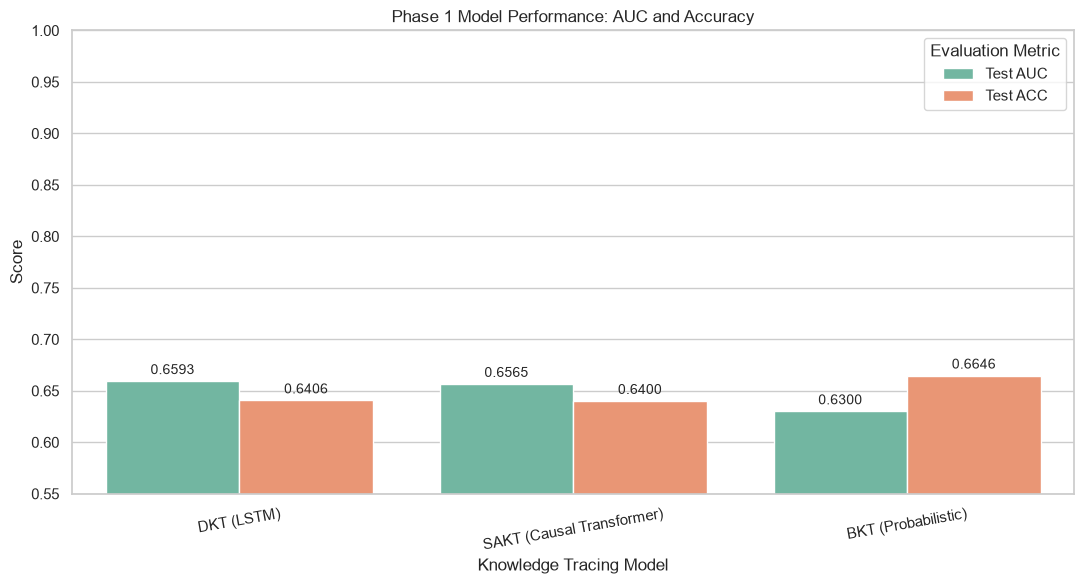

Figure saved to: /Users/tolulopesoetan/Desktop/msc_kt_ednet/results/figures/phase1_auc_accuracy_comparison.png


In [36]:
performance_long = results_df.melt(
    id_vars="Model",
    value_vars=["Test AUC", "Test ACC"],
    var_name="Metric",
    value_name="Score",
)

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=performance_long,
    x="Model",
    y="Score",
    hue="Metric",
    palette="Set2",
    ax=ax,
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f",
        padding=3,
        fontsize=10,
    )

ax.set_ylim(0.55, 1.00)
ax.set_title("Phase 1 Model Performance: AUC and Accuracy")
ax.set_xlabel("Knowledge Tracing Model")
ax.set_ylabel("Score")
ax.legend(title="Evaluation Metric", loc="upper right")
ax.tick_params(axis="x", rotation=10)

fig.tight_layout()

performance_figure_path = (
    FIGURES_DIR / "phase1_auc_accuracy_comparison.png"
)

fig.savefig(
    performance_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(f"Figure saved to: {performance_figure_path}")


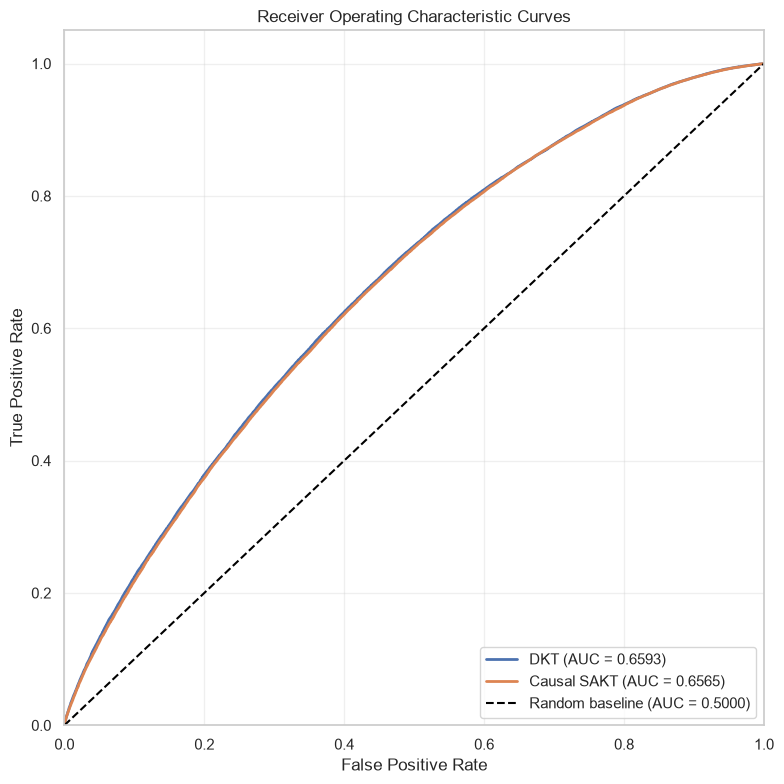

Figure saved to: /Users/tolulopesoetan/Desktop/msc_kt_ednet/results/figures/phase1_roc_curves.png


In [37]:
dkt_fpr, dkt_tpr, _ = roc_curve(
    y_test_clean,
    dkt_predictions_clean,
)

sakt_fpr, sakt_tpr, _ = roc_curve(
    y_test_clean,
    sakt_predictions_clean,
)

fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(
    dkt_fpr,
    dkt_tpr,
    linewidth=2,
    label=f"DKT (AUC = {dkt_auc:.4f})",
)

ax.plot(
    sakt_fpr,
    sakt_tpr,
    linewidth=2,
    label=f"Causal SAKT (AUC = {sakt_auc:.4f})",
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    linewidth=1.5,
    label="Random baseline (AUC = 0.5000)",
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.set_title("Receiver Operating Characteristic Curves")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)

fig.tight_layout()

roc_figure_path = FIGURES_DIR / "phase1_roc_curves.png"

fig.savefig(
    roc_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(f"Figure saved to: {roc_figure_path}")


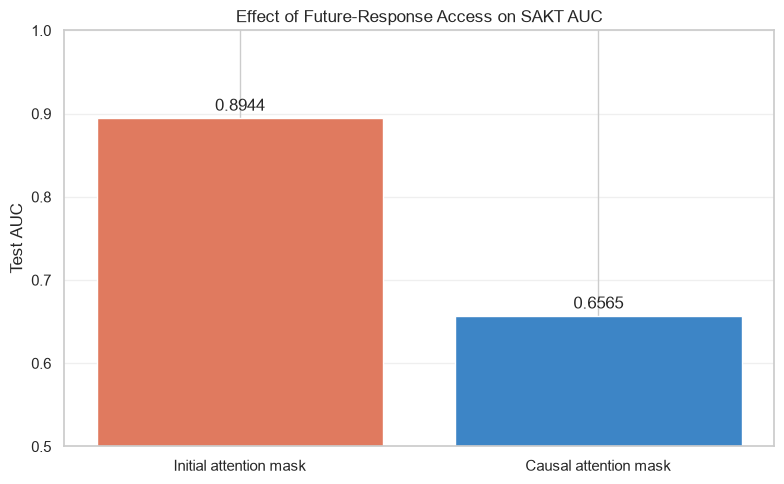

Figure saved to: /Users/tolulopesoetan/Desktop/msc_kt_ednet/results/figures/sakt_temporal_leakage_diagnostic.png


In [38]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    sakt_diagnostic_df["Evaluation"],
    sakt_diagnostic_df["Test AUC"],
    color=["#E07A5F", "#3D85C6"],
)

ax.bar_label(
    bars,
    labels=[f"{value:.4f}" for value in sakt_diagnostic_df["Test AUC"]],
    padding=3,
)
ax.set_ylim(0.5, 1.0)
ax.set_title("Effect of Future-Response Access on SAKT AUC")
ax.set_xlabel("")
ax.set_ylabel("Test AUC")
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
diagnostic_figure_path = FIGURES_DIR / "sakt_temporal_leakage_diagnostic.png"
fig.savefig(diagnostic_figure_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Figure saved to: {diagnostic_figure_path}")


## BKT Skill-Label Sensitivity Analysis

The Riiid questions can contain multiple skill tags. This experiment evaluates how the choice of a single skill representation affects BKT performance. The first three available tags and the question-part classification are compared using the same student-level train/test split.


In [39]:
questions_extended = pd.read_csv(
    QUESTIONS_PATH,
    usecols=["question_id", "tags", "part"],
)

questions_extended["tags"] = (
    questions_extended["tags"]
    .fillna("-1")
    .astype(str)
)

expanded_tags = questions_extended["tags"].str.split(
    " ",
    expand=True,
)

questions_extended["tag_2"] = (
    expanded_tags[1]
    if 1 in expanded_tags.columns
    else "missing_tag_2"
)

questions_extended["tag_3"] = (
    expanded_tags[2]
    if 2 in expanded_tags.columns
    else "missing_tag_3"
)

questions_extended["tag_2"] = (
    questions_extended["tag_2"]
    .fillna("missing_tag_2")
)

questions_extended["tag_3"] = (
    questions_extended["tag_3"]
    .fillna("missing_tag_3")
)

questions_extended["part_label"] = (
    "part_" + questions_extended["part"].astype(str)
)

question_metadata = questions_extended.set_index("question_id")

for dataset in [train_df, test_df]:
    dataset["tag_2"] = dataset["content_id"].map(
        question_metadata["tag_2"]
    )
    dataset["tag_3"] = dataset["content_id"].map(
        question_metadata["tag_3"]
    )
    dataset["part_label"] = dataset["content_id"].map(
        question_metadata["part_label"]
    )

required_skill_columns = [
    "tag_1",
    "tag_2",
    "tag_3",
    "part_label",
]

if train_df[required_skill_columns].isna().any().any():
    raise ValueError("Missing training skill labels were detected.")

if test_df[required_skill_columns].isna().any().any():
    raise ValueError("Missing testing skill labels were detected.")

print("Additional skill labels prepared.")


Additional skill labels prepared.


In [40]:
skill_strategies = {
    "tag_1": "First question tag",
    "tag_2": "Second question tag",
    "tag_3": "Third question tag",
    "part_label": "Question part",
}

tag_ablation_results = []

for skill_column, strategy_name in skill_strategies.items():
    print(f"Training BKT with {strategy_name.lower()}.")

    temporary_model = BKTModel(seed=SEED)

    temporary_train = train_df[
        ["user_id", skill_column, "answered_correctly"]
    ].rename(columns={
        skill_column: "skill_name",
        "answered_correctly": "correct",
    })

    temporary_test = test_df[
        ["user_id", skill_column, "answered_correctly"]
    ].rename(columns={
        skill_column: "skill_name",
        "answered_correctly": "correct",
    })

    temporary_model.fit(data=temporary_train)
    temporary_predictions = temporary_model.predict(
        data=temporary_test
    )

    strategy_auc = roc_auc_score(
        temporary_predictions["correct"],
        temporary_predictions["correct_predictions"],
    )

    tag_ablation_results.append({
        "Skill Strategy": strategy_name,
        "Column": skill_column,
        "Test AUC": strategy_auc,
    })

    print(f"{strategy_name} AUC: {strategy_auc:.4f}")

    del temporary_model
    del temporary_train
    del temporary_test
    del temporary_predictions
    gc.collect()

tag_ablation_df = pd.DataFrame(tag_ablation_results)
tag_ablation_df = tag_ablation_df.sort_values(
    "Test AUC",
    ascending=False,
).reset_index(drop=True)

display(
    tag_ablation_df.round({
        "Test AUC": 5,
    })
)

tag_ablation_df.to_csv(
    TABLES_DIR / "bkt_skill_label_sensitivity.csv",
    index=False,
)


Training BKT with first question tag.
First question tag AUC: 0.6300
Training BKT with second question tag.
Second question tag AUC: 0.6291
Training BKT with third question tag.
Third question tag AUC: 0.6240
Training BKT with question part.
Question part AUC: 0.6339


,Skill Strategy,Column,Test AUC
0,Question part,part_label,0.63392
1,First question tag,tag_1,0.62997
2,Second question tag,tag_2,0.62909
3,Third question tag,tag_3,0.62403


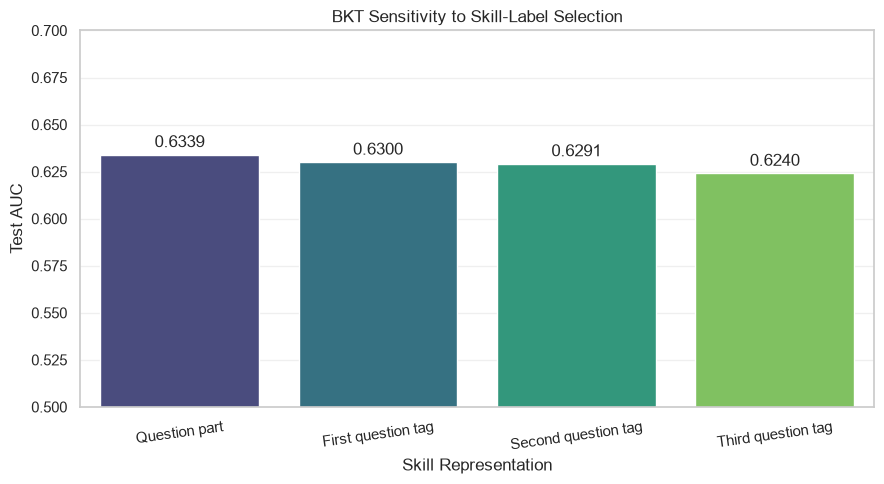

Figure saved to: /Users/tolulopesoetan/Desktop/msc_kt_ednet/results/figures/bkt_skill_label_sensitivity.png


In [41]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=tag_ablation_df,
    x="Skill Strategy",
    y="Test AUC",
    hue="Skill Strategy",
    palette="viridis",
    legend=False,
    ax=ax,
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f",
        padding=3,
    )

ax.set_ylim(0.50, 0.70)
ax.set_title("BKT Sensitivity to Skill-Label Selection")
ax.set_xlabel("Skill Representation")
ax.set_ylabel("Test AUC")
ax.tick_params(axis="x", rotation=8)
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

sensitivity_figure_path = (
    FIGURES_DIR / "bkt_skill_label_sensitivity.png"
)

fig.savefig(
    sensitivity_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(f"Figure saved to: {sensitivity_figure_path}")


## Sequence-Length Ablation

This experiment examines whether increasing the maximum learner-history length from 100 to 200 interactions improves predictive performance. DKT and causal SAKT are retrained using identical student partitions and evaluation procedures.


In [42]:
ABLATION_SEQ_LEN = 200

skills_200, responses_200, users_200 = create_sequence_data(
    final_df,
    ABLATION_SEQ_LEN,
)

inputs_200 = []
targets_200 = []

for skill_sequence, response_sequence in zip(
    skills_200,
    responses_200,
):
    tokens = (
        skill_sequence[:-1] * 2
        + response_sequence[:-1]
        + 1
    )

    inputs_200.append(tokens)
    targets_200.append(response_sequence[1:])

X_200 = pad_sequences(
    inputs_200,
    maxlen=ABLATION_SEQ_LEN,
    padding="pre",
    value=0,
)

y_200 = pad_sequences(
    targets_200,
    maxlen=ABLATION_SEQ_LEN,
    padding="pre",
    value=-1,
)

users_200 = np.asarray(users_200)

train_mask_200 = np.isin(users_200, training_users)
test_mask_200 = np.isin(users_200, testing_users)

X_train_200 = X_200[train_mask_200]
y_train_200 = y_200[train_mask_200, :, np.newaxis]

X_test_200 = X_200[test_mask_200]
y_test_200 = y_200[test_mask_200, :, np.newaxis]

valid_mask_200 = X_test_200 != 0
y_test_clean_200 = y_test_200[valid_mask_200].ravel()

print(f"Training shape: {X_train_200.shape}")
print(f"Testing shape:  {X_test_200.shape}")


Training shape: (15999, 200)
Testing shape:  (4000, 200)


In [43]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

dkt_200_inputs = Input(
    shape=(ABLATION_SEQ_LEN,),
    name="dkt_200_inputs",
)

dkt_200_embedding = Embedding(
    input_dim=vocab_size,
    output_dim=64,
    mask_zero=True,
)(dkt_200_inputs)

dkt_200_hidden = LSTM(
    64,
    return_sequences=True,
)(dkt_200_embedding)

dkt_200_outputs = Dense(
    1,
    activation="sigmoid",
)(dkt_200_hidden)

dkt_200_model = KerasModel(
    inputs=dkt_200_inputs,
    outputs=dkt_200_outputs,
    name="dkt_200",
)

dkt_200_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
)

dkt_200_stopping = EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=2,
    restore_best_weights=True,
)

dkt_200_history = dkt_200_model.fit(
    X_train_200,
    y_train_200,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[dkt_200_stopping],
    verbose=1,
)

dkt_200_predictions = dkt_200_model.predict(
    X_test_200,
    verbose=0,
)

dkt_200_predictions_clean = dkt_200_predictions[
    valid_mask_200
].ravel()

dkt_200_auc = roc_auc_score(
    y_test_clean_200,
    dkt_200_predictions_clean,
)

print(f"DKT-100 AUC: {dkt_auc:.4f}")
print(f"DKT-200 AUC: {dkt_200_auc:.4f}")


Epoch 1/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - loss: 0.6377 - val_loss: 0.6330
Epoch 2/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - loss: 0.6325 - val_loss: 0.6317
Epoch 3/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - loss: 0.6311 - val_loss: 0.6303
Epoch 4/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - loss: 0.6299 - val_loss: 0.6296
Epoch 5/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - loss: 0.6292 - val_loss: 0.6292
Epoch 6/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - loss: 0.6286 - val_loss: 0.6288
Epoch 7/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - loss: 0.6280 - val_loss: 0.6284
Epoch 8/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - loss: 0.6275 - val_loss: 0.6282
Epoch 9/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - loss: 0.6271 - val_loss: 0.6279
Epoch 10/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 12s 54ms/step - loss: 0.6268 - val_loss: 0.6278
DKT-100 AUC: 0.6593
DKT-200 AUC: 0.6574


In [44]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

sakt_200_inputs = Input(
    shape=(ABLATION_SEQ_LEN,),
    name="sakt_200_inputs",
)

sakt_200_interactions = Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dimension,
    mask_zero=False,
)(sakt_200_inputs)

positions_200 = tf.range(ABLATION_SEQ_LEN)

sakt_200_positions = Embedding(
    input_dim=ABLATION_SEQ_LEN,
    output_dim=embedding_dimension,
)(positions_200)

sakt_200_x = sakt_200_interactions + sakt_200_positions

sakt_200_mask = CausalPaddingMask()(sakt_200_inputs)

sakt_200_attention = MultiHeadAttention(
    num_heads=attention_heads,
    key_dim=embedding_dimension,
)(
    query=sakt_200_x,
    value=sakt_200_x,
    key=sakt_200_x,
    attention_mask=sakt_200_mask,
)

sakt_200_x = Add()([
    sakt_200_x,
    sakt_200_attention,
])
sakt_200_x = LayerNormalization(epsilon=1e-6)(
    sakt_200_x
)

sakt_200_ffn = FeedForwardNetwork(
    model_dimension=embedding_dimension,
    hidden_dimension=feedforward_dimension,
)(sakt_200_x)

sakt_200_x = Add()([sakt_200_x, sakt_200_ffn])
sakt_200_x = LayerNormalization(epsilon=1e-6)(
    sakt_200_x
)

sakt_200_outputs = Dense(
    1,
    activation="sigmoid",
)(sakt_200_x)

sakt_200_model = KerasModel(
    inputs=sakt_200_inputs,
    outputs=sakt_200_outputs,
    name="causal_sakt_200",
)

sakt_200_model.compile(
    optimizer="adam",
    loss=masked_binary_crossentropy,
)

sakt_200_stopping = EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=2,
    restore_best_weights=True,
)

sakt_200_history = sakt_200_model.fit(
    X_train_200,
    y_train_200,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[sakt_200_stopping],
    verbose=1,
)

sakt_200_predictions = sakt_200_model.predict(
    X_test_200,
    verbose=0,
)

sakt_200_predictions_clean = sakt_200_predictions[
    valid_mask_200
].ravel()

sakt_200_auc = roc_auc_score(
    y_test_clean_200,
    sakt_200_predictions_clean,
)

print(f"Causal SAKT-100 AUC: {sakt_auc:.4f}")
print(f"Causal SAKT-200 AUC: {sakt_200_auc:.4f}")


Epoch 1/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 24s 99ms/step - loss: 0.6475 - val_loss: 0.6345
Epoch 2/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 22s 99ms/step - loss: 0.6344 - val_loss: 0.6331
Epoch 3/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 23s 101ms/step - loss: 0.6331 - val_loss: 0.6323
Epoch 4/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 23s 103ms/step - loss: 0.6321 - val_loss: 0.6316
Epoch 5/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 22s 99ms/step - loss: 0.6310 - val_loss: 0.6309
Epoch 6/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 27s 122ms/step - loss: 0.6303 - val_loss: 0.6305
Epoch 7/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 28s 125ms/step - loss: 0.6296 - val_loss: 0.6302
Epoch 8/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 28s 126ms/step - loss: 0.6290 - val_loss: 0.6300
Epoch 9/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 28s 125ms/step - loss: 0.6285 - val_loss: 0.6298
Epoch 10/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 29s 129ms/step - loss: 0.6280 - val_loss: 0.6297
Causal SAKT-100 AUC: 0.6565
Causal SAKT-200 AUC: 0.6537


,Model,Maximum Sequence Length,Test AUC
0,DKT,100,0.65930
1,DKT,200,0.65743
2,SAKT,100,0.65655
3,SAKT,200,0.65367


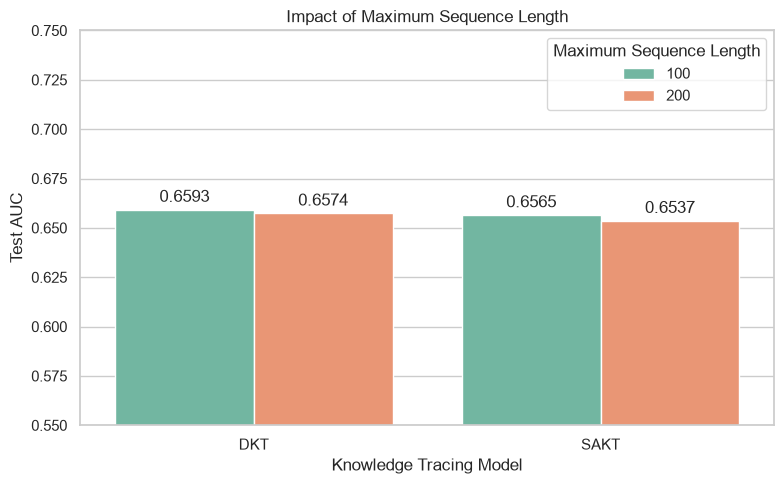

In [45]:
sequence_ablation_df = pd.DataFrame({
    "Model": ["DKT", "DKT", "SAKT", "SAKT"],
    "Maximum Sequence Length": [100, 200, 100, 200],
    "Test AUC": [
        dkt_auc,
        dkt_200_auc,
        sakt_auc,
        sakt_200_auc,
    ],
})

display(
    sequence_ablation_df.round({
        "Test AUC": 5,
    })
)

sequence_ablation_df.to_csv(
    TABLES_DIR / "sequence_length_ablation.csv",
    index=False,
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=sequence_ablation_df,
    x="Model",
    y="Test AUC",
    hue="Maximum Sequence Length",
    palette="Set2",
    ax=ax,
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

ax.set_ylim(0.55, 0.75)
ax.set_title("Impact of Maximum Sequence Length")
ax.set_xlabel("Knowledge Tracing Model")
ax.set_ylabel("Test AUC")
ax.legend(title="Maximum Sequence Length")

fig.tight_layout()

ablation_figure_path = (
    FIGURES_DIR / "sequence_length_ablation.png"
)

fig.savefig(
    ablation_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)


## DKT Hyperparameter Tuning

Embedding dimension, LSTM hidden units, and learning rate are evaluated using a held-out validation subset of the training students. The test partition is excluded from model selection to preserve an unbiased final evaluation.


In [46]:
training_indices = np.arange(X_train.shape[0])

development_indices, validation_indices = train_test_split(
    training_indices,
    test_size=0.1,
    random_state=SEED,
    shuffle=True,
)

X_development = X_train[development_indices]
y_development = y_train[development_indices]

X_validation = X_train[validation_indices]
y_validation = y_train[validation_indices]

validation_mask = X_validation != 0
y_validation_clean = y_validation[validation_mask].ravel()

print(f"Development students: {len(X_development):,}")
print(f"Validation students:  {len(X_validation):,}")


Development students: 14,399
Validation students:  1,600


In [47]:
dkt_parameter_grid = {
    "embedding_dimension": [32, 64],
    "lstm_units": [32, 64],
    "learning_rate": [1e-3, 5e-4],
}

parameter_names = list(dkt_parameter_grid)

dkt_configurations = [
    dict(zip(parameter_names, values))
    for values in itertools.product(
        *(dkt_parameter_grid[name] for name in parameter_names)
    )
]

print(f"DKT configurations: {len(dkt_configurations)}")


DKT configurations: 8


In [48]:
dkt_tuning_results = []

for run_number, configuration in enumerate(
    dkt_configurations,
    start=1,
):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)

    print(
        f"Run {run_number}/{len(dkt_configurations)}: "
        f"{configuration}"
    )

    tuning_inputs = Input(shape=(MAX_SEQ_LEN,))

    tuning_embedding = Embedding(
        input_dim=vocab_size,
        output_dim=configuration["embedding_dimension"],
        mask_zero=True,
    )(tuning_inputs)

    tuning_hidden = LSTM(
        configuration["lstm_units"],
        return_sequences=True,
    )(tuning_embedding)

    tuning_outputs = Dense(
        1,
        activation="sigmoid",
    )(tuning_hidden)

    tuning_model = KerasModel(
        inputs=tuning_inputs,
        outputs=tuning_outputs,
    )

    tuning_model.compile(
        optimizer=Adam(
            learning_rate=configuration["learning_rate"]
        ),
        loss="binary_crossentropy",
    )

    tuning_stopping = EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=2,
        restore_best_weights=True,
    )

    tuning_history = tuning_model.fit(
        X_development,
        y_development,
        validation_data=(X_validation, y_validation),
        epochs=10,
        batch_size=64,
        callbacks=[tuning_stopping],
        verbose=0,
    )

    validation_predictions = tuning_model.predict(
        X_validation,
        verbose=0,
    )

    validation_predictions_clean = validation_predictions[
        validation_mask
    ].ravel()

    validation_auc = roc_auc_score(
        y_validation_clean,
        validation_predictions_clean,
    )

    dkt_tuning_results.append({
        **configuration,
        "epochs_trained": len(tuning_history.history["loss"]),
        "Validation AUC": validation_auc,
    })

    print(f"Validation AUC: {validation_auc:.4f}")

    del tuning_model
    del validation_predictions
    gc.collect()


Run 1/8: {'embedding_dimension': 32, 'lstm_units': 32, 'learning_rate': 0.001}
Validation AUC: 0.6576
Run 2/8: {'embedding_dimension': 32, 'lstm_units': 32, 'learning_rate': 0.0005}
Validation AUC: 0.6553
Run 3/8: {'embedding_dimension': 32, 'lstm_units': 64, 'learning_rate': 0.001}
Validation AUC: 0.6580
Run 4/8: {'embedding_dimension': 32, 'lstm_units': 64, 'learning_rate': 0.0005}
Validation AUC: 0.6557
Run 5/8: {'embedding_dimension': 64, 'lstm_units': 32, 'learning_rate': 0.001}
Validation AUC: 0.6586
Run 6/8: {'embedding_dimension': 64, 'lstm_units': 32, 'learning_rate': 0.0005}
Validation AUC: 0.6565
Run 7/8: {'embedding_dimension': 64, 'lstm_units': 64, 'learning_rate': 0.001}
Validation AUC: 0.6592
Run 8/8: {'embedding_dimension': 64, 'lstm_units': 64, 'learning_rate': 0.0005}
Validation AUC: 0.6571


In [49]:
dkt_tuning_df = pd.DataFrame(dkt_tuning_results)

dkt_tuning_df = dkt_tuning_df.sort_values(
    "Validation AUC",
    ascending=False,
).reset_index(drop=True)

display(
    dkt_tuning_df.round({
        "learning_rate": 5,
        "Validation AUC": 5,
    })
)

best_dkt_configuration = dkt_tuning_df.iloc[0]

print("Best validation configuration:")
print(
    f"Embedding dimension: "
    f"{int(best_dkt_configuration['embedding_dimension'])}"
)
print(
    f"LSTM units: "
    f"{int(best_dkt_configuration['lstm_units'])}"
)
print(
    f"Learning rate: "
    f"{best_dkt_configuration['learning_rate']:.5f}"
)

dkt_tuning_df.to_csv(
    TABLES_DIR / "dkt_hyperparameter_tuning.csv",
    index=False,
)


,embedding_dimension,lstm_units,learning_rate,epochs_trained,Validation AUC
0,64,64,0.00100,10,0.65918
1,64,32,0.00100,10,0.65865
2,32,64,0.00100,10,0.65799
3,32,32,0.00100,10,0.65761
4,64,64,0.00050,10,0.65706
5,64,32,0.00050,10,0.65646
6,32,64,0.00050,10,0.65567
7,32,32,0.00050,10,0.65534


Best validation configuration:
Embedding dimension: 64
LSTM units: 64
Learning rate: 0.00100


## SAKT Hyperparameter Tuning

The number of attention heads and feed-forward network dimension are evaluated using the held-out validation students. Causal attention and padding masks are applied consistently across all configurations.


In [50]:
sakt_parameter_grid = {
    "embedding_dimension": [64],
    "attention_heads": [2, 4, 8],
    "feedforward_dimension": [64, 128],
    "learning_rate": [1e-3],
}

sakt_parameter_names = list(sakt_parameter_grid)

sakt_configurations = [
    dict(zip(sakt_parameter_names, values))
    for values in itertools.product(
        *(
            sakt_parameter_grid[name]
            for name in sakt_parameter_names
        )
    )
]

print(f"SAKT configurations: {len(sakt_configurations)}")


SAKT configurations: 6


In [51]:
sakt_tuning_results = []

for run_number, configuration in enumerate(
    sakt_configurations,
    start=1,
):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)

    print(
        f"Run {run_number}/{len(sakt_configurations)}: "
        f"{configuration}"
    )

    tuning_inputs = Input(
        shape=(MAX_SEQ_LEN,),
        name="interaction_inputs",
    )

    interaction_embeddings = Embedding(
        input_dim=vocab_size,
        output_dim=configuration["embedding_dimension"],
        mask_zero=False,
    )(tuning_inputs)

    tuning_positions = tf.range(MAX_SEQ_LEN)

    position_embeddings = Embedding(
        input_dim=MAX_SEQ_LEN,
        output_dim=configuration["embedding_dimension"],
    )(tuning_positions)

    tuning_x = interaction_embeddings + position_embeddings

    tuning_attention_mask = CausalPaddingMask()(
        tuning_inputs
    )

    tuning_attention = MultiHeadAttention(
        num_heads=configuration["attention_heads"],
        key_dim=configuration["embedding_dimension"],
    )(
        query=tuning_x,
        value=tuning_x,
        key=tuning_x,
        attention_mask=tuning_attention_mask,
    )

    tuning_x = Add()([
        tuning_x,
        tuning_attention,
    ])
    tuning_x = LayerNormalization(
        epsilon=1e-6,
    )(tuning_x)

    tuning_feedforward = FeedForwardNetwork(
        model_dimension=configuration["embedding_dimension"],
        hidden_dimension=configuration[
            "feedforward_dimension"
        ],
    )(tuning_x)

    tuning_x = Add()([
        tuning_x,
        tuning_feedforward,
    ])
    tuning_x = LayerNormalization(
        epsilon=1e-6,
    )(tuning_x)

    tuning_outputs = Dense(
        1,
        activation="sigmoid",
    )(tuning_x)

    tuning_model = KerasModel(
        inputs=tuning_inputs,
        outputs=tuning_outputs,
    )

    if tuning_model.output_shape != (
        None,
        MAX_SEQ_LEN,
        1,
    ):
        raise ValueError(
            f"Unexpected output shape: "
            f"{tuning_model.output_shape}"
        )

    tuning_model.compile(
        optimizer=Adam(
            learning_rate=configuration["learning_rate"]
        ),
        loss=masked_binary_crossentropy,
    )

    tuning_stopping = EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=2,
        restore_best_weights=True,
    )

    tuning_history = tuning_model.fit(
        X_development,
        y_development,
        validation_data=(X_validation, y_validation),
        epochs=10,
        batch_size=64,
        callbacks=[tuning_stopping],
        verbose=0,
    )

    validation_predictions = tuning_model.predict(
        X_validation,
        verbose=0,
    )

    validation_predictions_clean = validation_predictions[
        validation_mask
    ].ravel()

    validation_auc = roc_auc_score(
        y_validation_clean,
        validation_predictions_clean,
    )

    sakt_tuning_results.append({
        **configuration,
        "epochs_trained": len(tuning_history.history["loss"]),
        "Validation AUC": validation_auc,
    })

    print(f"Validation AUC: {validation_auc:.4f}")

    del tuning_model
    del validation_predictions
    gc.collect()


Run 1/6: {'embedding_dimension': 64, 'attention_heads': 2, 'feedforward_dimension': 64, 'learning_rate': 0.001}
Validation AUC: 0.6528
Run 2/6: {'embedding_dimension': 64, 'attention_heads': 2, 'feedforward_dimension': 128, 'learning_rate': 0.001}
Validation AUC: 0.6534
Run 3/6: {'embedding_dimension': 64, 'attention_heads': 4, 'feedforward_dimension': 64, 'learning_rate': 0.001}
Validation AUC: 0.6530
Run 4/6: {'embedding_dimension': 64, 'attention_heads': 4, 'feedforward_dimension': 128, 'learning_rate': 0.001}
Validation AUC: 0.6529
Run 5/6: {'embedding_dimension': 64, 'attention_heads': 8, 'feedforward_dimension': 64, 'learning_rate': 0.001}
Validation AUC: 0.6538
Run 6/6: {'embedding_dimension': 64, 'attention_heads': 8, 'feedforward_dimension': 128, 'learning_rate': 0.001}
Validation AUC: 0.6536


In [52]:
sakt_tuning_df = pd.DataFrame(sakt_tuning_results)

sakt_tuning_df = sakt_tuning_df.sort_values(
    "Validation AUC",
    ascending=False,
).reset_index(drop=True)

display(
    sakt_tuning_df.round({
        "learning_rate": 5,
        "Validation AUC": 5,
    })
)

best_sakt_configuration = sakt_tuning_df.iloc[0]

print("Best validation configuration:")
print(
    f"Embedding dimension: "
    f"{int(best_sakt_configuration['embedding_dimension'])}"
)
print(
    f"Attention heads: "
    f"{int(best_sakt_configuration['attention_heads'])}"
)
print(
    f"Feed-forward dimension: "
    f"{int(best_sakt_configuration['feedforward_dimension'])}"
)
print(
    f"Learning rate: "
    f"{best_sakt_configuration['learning_rate']:.5f}"
)

sakt_tuning_df.to_csv(
    TABLES_DIR / "sakt_hyperparameter_tuning.csv",
    index=False,
)


,embedding_dimension,attention_heads,feedforward_dimension,learning_rate,epochs_trained,Validation AUC
0,64,8,64,0.00100,10,0.65377
1,64,8,128,0.00100,10,0.65362
2,64,2,128,0.00100,10,0.65336
3,64,4,64,0.00100,10,0.65302
4,64,4,128,0.00100,10,0.65286
5,64,2,64,0.00100,10,0.65284


Best validation configuration:
Embedding dimension: 64
Attention heads: 8
Feed-forward dimension: 64
Learning rate: 0.00100


## Experimental Configuration and Reproducibility Ledger

The final data constraints, model configurations, and software versions are recorded to support reproducibility. Hyperparameters are taken from the validation-based tuning procedure.


In [53]:
configuration_records = [
    {
        "Category": "Data",
        "Parameter": "Student sample",
        "Value": TARGET_STUDENTS,
    },
    {
        "Category": "Data",
        "Parameter": "Random seed",
        "Value": SEED,
    },
    {
        "Category": "Data",
        "Parameter": "Train/test method",
        "Value": "GroupShuffleSplit",
    },
    {
        "Category": "Data",
        "Parameter": "Training students",
        "Value": train_df["user_id"].nunique(),
    },
    {
        "Category": "Data",
        "Parameter": "Testing students",
        "Value": test_df["user_id"].nunique(),
    },
    {
        "Category": "Data",
        "Parameter": "Baseline sequence length",
        "Value": MAX_SEQ_LEN,
    },
    {
        "Category": "Data",
        "Parameter": "Ablation sequence length",
        "Value": ABLATION_SEQ_LEN,
    },
    {
        "Category": "Data",
        "Parameter": "Primary skill representation",
        "Value": "tag_1",
    },
    {
        "Category": "Data",
        "Parameter": "Encoded skills",
        "Value": num_skills,
    },
    {
        "Category": "DKT",
        "Parameter": "Embedding dimension",
        "Value": int(
            best_dkt_configuration["embedding_dimension"]
        ),
    },
    {
        "Category": "DKT",
        "Parameter": "LSTM units",
        "Value": int(
            best_dkt_configuration["lstm_units"]
        ),
    },
    {
        "Category": "DKT",
        "Parameter": "Learning rate",
        "Value": best_dkt_configuration["learning_rate"],
    },
    {
        "Category": "SAKT",
        "Parameter": "Embedding dimension",
        "Value": int(
            best_sakt_configuration["embedding_dimension"]
        ),
    },
    {
        "Category": "SAKT",
        "Parameter": "Attention heads",
        "Value": int(
            best_sakt_configuration["attention_heads"]
        ),
    },
    {
        "Category": "SAKT",
        "Parameter": "Feed-forward dimension",
        "Value": int(
            best_sakt_configuration[
                "feedforward_dimension"
            ]
        ),
    },
    {
        "Category": "SAKT",
        "Parameter": "Learning rate",
        "Value": best_sakt_configuration["learning_rate"],
    },
    {
        "Category": "Training",
        "Parameter": "Batch size",
        "Value": 64,
    },
    {
        "Category": "Training",
        "Parameter": "Maximum epochs",
        "Value": 10,
    },
    {
        "Category": "Training",
        "Parameter": "Early-stopping patience",
        "Value": 2,
    },
]

configuration_df = pd.DataFrame(configuration_records)

display(configuration_df)

configuration_df.to_csv(
    TABLES_DIR / "experimental_configuration.csv",
    index=False,
)


,Category,Parameter,Value
0,Data,Student sample,20000
1,Data,Random seed,42
2,Data,Train/test method,GroupShuffleSplit
3,Data,Training students,16000
4,Data,Testing students,4000
5,Data,Baseline sequence length,100
6,Data,Ablation sequence length,200
7,Data,Primary skill representation,tag_1
8,Data,Encoded skills,117
9,DKT,Embedding dimension,64


In [54]:
environment_df = pd.DataFrame({
    "Package": list(installed_versions.keys()),
    "Version": list(installed_versions.values()),
})

tensorflow_record = pd.DataFrame({
    "Package": ["tensorflow"],
    "Version": [tf.__version__],
})

environment_df = pd.concat(
    [environment_df, tensorflow_record],
    ignore_index=True,
)

environment_df["Python"] = (
    f"{os.sys.version_info.major}."
    f"{os.sys.version_info.minor}."
    f"{os.sys.version_info.micro}"
)

environment_df["Platform"] = os.sys.platform

display(environment_df)

environment_df.to_csv(
    TABLES_DIR / "software_environment.csv",
    index=False,
)

print(f"Configuration records saved in: {TABLES_DIR}")


,Package,Version,Python,Platform
0,numpy,1.26.4,3.12.13,darwin
1,pandas,2.2.3,3.12.13,darwin
2,scipy,1.13.1,3.12.13,darwin
3,scikit-learn,1.6.1,3.12.13,darwin
4,pyBKT,1.4.2,3.12.13,darwin
5,tensorflow,2.21.0,3.12.13,darwin
6,tensorflow,2.21.0,3.12.13,darwin


Configuration records saved in: /Users/tolulopesoetan/Desktop/msc_kt_ednet/results/tables


## Performance by Learner History Length

Model performance may depend on the amount of historical information available for each learner. Test students are grouped into four history-length strata, and AUC is calculated independently within each group.


In [55]:
test_sequence_users = sequence_users[test_mask]

user_id_matrix = np.repeat(
    test_sequence_users[:, np.newaxis],
    MAX_SEQ_LEN,
    axis=1,
)

valid_user_ids = user_id_matrix[valid_sequence_mask]

dl_master_df = pd.DataFrame({
    "user_id": valid_user_ids,
    "true_target": y_test_clean,
    "DKT_probability": dkt_predictions_clean,
    "SAKT_probability": sakt_predictions_clean,
})

dl_master_df = dl_master_df.merge(
    test_user_lengths,
    on="user_id",
    how="left",
    validate="many_to_one",
)

bkt_master_df = bkt_preds.copy()

bkt_master_df = bkt_master_df.merge(
    test_user_lengths,
    on="user_id",
    how="left",
    validate="many_to_one",
)

if dl_master_df["total_interactions"].isna().any():
    raise ValueError("Missing DKT/SAKT learner-history counts.")

if bkt_master_df["total_interactions"].isna().any():
    raise ValueError("Missing BKT learner-history counts.")

print(
    f"Deep-learning predictions: "
    f"{len(dl_master_df):,}"
)
print(
    f"BKT predictions: "
    f"{len(bkt_master_df):,}"
)


Deep-learning predictions: 219,214
BKT predictions: 982,533


In [56]:
history_boundaries = [0, 20, 50, 100, np.inf]

history_labels = [
    "Cold Start (2-20)",
    "Developing (21-50)",
    "Established (51-100)",
    "Power Users (100+)",
]

dl_master_df["History Stratum"] = pd.cut(
    dl_master_df["total_interactions"],
    bins=history_boundaries,
    labels=history_labels,
    include_lowest=True,
)

bkt_master_df["History Stratum"] = pd.cut(
    bkt_master_df["total_interactions"],
    bins=history_boundaries,
    labels=history_labels,
    include_lowest=True,
)

print("Learner-history strata assigned.")


Learner-history strata assigned.


In [57]:
def calculate_auc_if_defined(y_true, probabilities):
    if len(y_true) == 0 or pd.Series(y_true).nunique() < 2:
        return np.nan

    return roc_auc_score(y_true, probabilities)


history_results = []

for history_stratum in history_labels:
    dl_subset = dl_master_df[
        dl_master_df["History Stratum"] == history_stratum
    ]

    bkt_subset = bkt_master_df[
        bkt_master_df["History Stratum"] == history_stratum
    ]

    history_results.extend([
        {
            "History Stratum": history_stratum,
            "Model": "BKT",
            "Test AUC": calculate_auc_if_defined(
                bkt_subset["correct"],
                bkt_subset["correct_predictions"],
            ),
            "Evaluated Interactions": len(bkt_subset),
        },
        {
            "History Stratum": history_stratum,
            "Model": "DKT",
            "Test AUC": calculate_auc_if_defined(
                dl_subset["true_target"],
                dl_subset["DKT_probability"],
            ),
            "Evaluated Interactions": len(dl_subset),
        },
        {
            "History Stratum": history_stratum,
            "Model": "SAKT",
            "Test AUC": calculate_auc_if_defined(
                dl_subset["true_target"],
                dl_subset["SAKT_probability"],
            ),
            "Evaluated Interactions": len(dl_subset),
        },
    ])

history_results_df = pd.DataFrame(history_results)

display(
    history_results_df.round({
        "Test AUC": 5,
    })
)

history_results_df.to_csv(
    TABLES_DIR / "performance_by_history_length.csv",
    index=False,
)


,History Stratum,Model,Test AUC,Evaluated Interactions
0,Cold Start (2-20),BKT,0.58728,9280
1,Cold Start (2-20),DKT,0.58668,8692
2,Cold Start (2-20),SAKT,0.58061,8692
3,Developing (21-50),BKT,0.66438,53621
4,Developing (21-50),DKT,0.68864,51974
5,Developing (21-50),SAKT,0.68801,51974
6,Established (51-100),BKT,0.62222,40013
7,Established (51-100),DKT,0.64676,39451
8,Established (51-100),SAKT,0.63833,39451
9,Power Users (100+),BKT,0.61827,879619


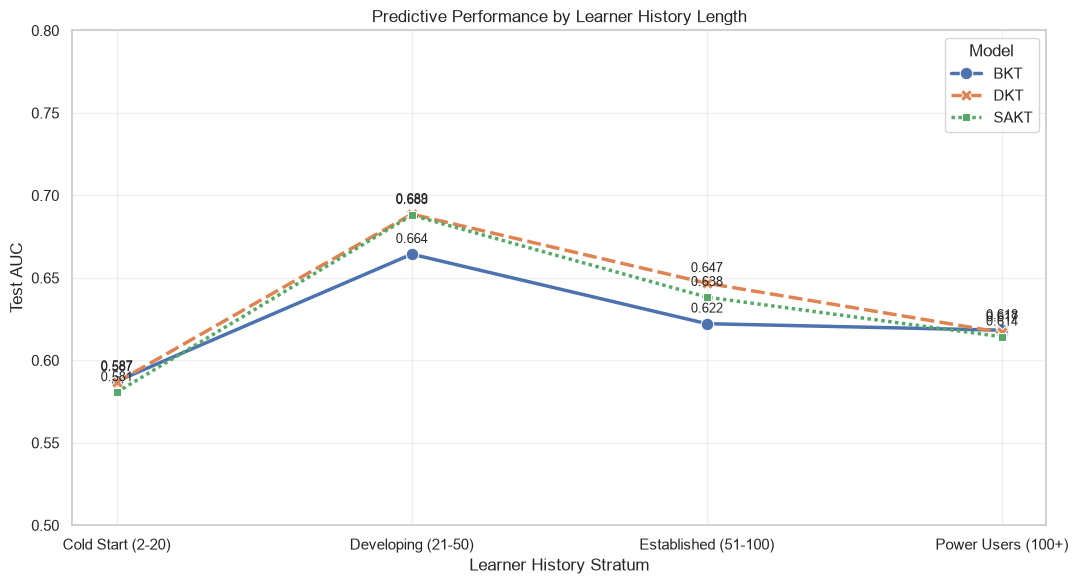

Figure saved to: /Users/tolulopesoetan/Desktop/msc_kt_ednet/results/figures/performance_by_history_length.png


In [58]:
fig, ax = plt.subplots(figsize=(11, 6))

sns.lineplot(
    data=history_results_df,
    x="History Stratum",
    y="Test AUC",
    hue="Model",
    style="Model",
    markers=True,
    linewidth=2.5,
    markersize=9,
    ax=ax,
)

for model_name in ["BKT", "DKT", "SAKT"]:
    model_results = history_results_df[
        history_results_df["Model"] == model_name
    ]

    for x_position, auc_value in enumerate(
        model_results["Test AUC"]
    ):
        ax.annotate(
            f"{auc_value:.3f}",
            (x_position, auc_value),
            xytext=(0, 8),
            textcoords="offset points",
            ha="center",
            fontsize=9,
        )

ax.set_ylim(0.50, 0.80)
ax.set_title(
    "Predictive Performance by Learner History Length"
)
ax.set_xlabel("Learner History Stratum")
ax.set_ylabel("Test AUC")
ax.legend(title="Model")
ax.grid(alpha=0.3)

fig.tight_layout()

history_figure_path = (
    FIGURES_DIR / "performance_by_history_length.png"
)

fig.savefig(
    history_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(f"Figure saved to: {history_figure_path}")


## Performance by Skill Frequency

Skills with limited training observations may be more difficult to model reliably. Skills are classified as rare when their training frequency falls within the lowest quartile. Model performance is then evaluated separately for rare and common skills.


In [59]:
target_skill_sequences = [
    skill_sequence[1:]
    for skill_sequence in sequence_skills
]

target_skill_matrix = pad_sequences(
    target_skill_sequences,
    maxlen=MAX_SEQ_LEN,
    padding="pre",
    value=-1,
)

target_skills_test = target_skill_matrix[test_mask]

valid_target_skills = target_skills_test[
    valid_sequence_mask
].ravel()

if len(valid_target_skills) != len(dl_master_df):
    raise ValueError(
        "Target skills are not aligned with predictions."
    )

dl_master_df["skill"] = valid_target_skills

skill_lookup = (
    final_df[["tag_1", "skill"]]
    .drop_duplicates()
    .assign(tag_1=lambda data: data["tag_1"].astype(str))
    .set_index("tag_1")["skill"]
    .to_dict()
)

bkt_master_df["skill"] = (
    bkt_master_df["skill_name"]
    .astype(str)
    .map(skill_lookup)
)

if bkt_master_df["skill"].isna().any():
    raise ValueError("Some BKT skills could not be encoded.")

bkt_master_df["skill"] = (
    bkt_master_df["skill"].astype(int)
)

print("Target skills aligned with model predictions.")


Target skills aligned with model predictions.


In [60]:
training_skill_frequency = (
    train_df["skill"]
    .value_counts()
    .sort_index()
)

rarity_threshold = training_skill_frequency.quantile(0.25)

rare_skills = training_skill_frequency[
    training_skill_frequency <= rarity_threshold
].index

common_skills = training_skill_frequency[
    training_skill_frequency > rarity_threshold
].index

dl_master_df["Skill Frequency Group"] = np.where(
    dl_master_df["skill"].isin(rare_skills),
    "Rare Skill (Bottom 25%)",
    "Common Skill (Top 75%)",
)

bkt_master_df["Skill Frequency Group"] = np.where(
    bkt_master_df["skill"].isin(rare_skills),
    "Rare Skill (Bottom 25%)",
    "Common Skill (Top 75%)",
)

print(
    f"Rare-skill threshold: "
    f"{rarity_threshold:,.0f} training interactions"
)
print(f"Rare skills: {len(rare_skills)}")
print(f"Common skills: {len(common_skills)}")


Rare-skill threshold: 13,984 training interactions
Rare skills: 30
Common skills: 87


In [61]:
skill_frequency_results = []

frequency_groups = [
    "Rare Skill (Bottom 25%)",
    "Common Skill (Top 75%)",
]

for frequency_group in frequency_groups:
    dl_subset = dl_master_df[
        dl_master_df["Skill Frequency Group"]
        == frequency_group
    ]

    bkt_subset = bkt_master_df[
        bkt_master_df["Skill Frequency Group"]
        == frequency_group
    ]

    skill_frequency_results.extend([
        {
            "Skill Frequency Group": frequency_group,
            "Model": "BKT",
            "Test AUC": calculate_auc_if_defined(
                bkt_subset["correct"],
                bkt_subset["correct_predictions"],
            ),
            "Evaluated Interactions": len(bkt_subset),
        },
        {
            "Skill Frequency Group": frequency_group,
            "Model": "DKT",
            "Test AUC": calculate_auc_if_defined(
                dl_subset["true_target"],
                dl_subset["DKT_probability"],
            ),
            "Evaluated Interactions": len(dl_subset),
        },
        {
            "Skill Frequency Group": frequency_group,
            "Model": "SAKT",
            "Test AUC": calculate_auc_if_defined(
                dl_subset["true_target"],
                dl_subset["SAKT_probability"],
            ),
            "Evaluated Interactions": len(dl_subset),
        },
    ])

skill_frequency_results_df = pd.DataFrame(
    skill_frequency_results
)

display(
    skill_frequency_results_df.round({
        "Test AUC": 5,
    })
)

skill_frequency_results_df.to_csv(
    TABLES_DIR / "performance_by_skill_frequency.csv",
    index=False,
)


,Skill Frequency Group,Model,Test AUC,Evaluated Interactions
0,Rare Skill (Bottom 25%),BKT,0.65083,52731
1,Rare Skill (Bottom 25%),DKT,0.59230,12612
2,Rare Skill (Bottom 25%),SAKT,0.58453,12612
3,Common Skill (Top 75%),BKT,0.62843,929802
4,Common Skill (Top 75%),DKT,0.66285,206602
5,Common Skill (Top 75%),SAKT,0.66034,206602


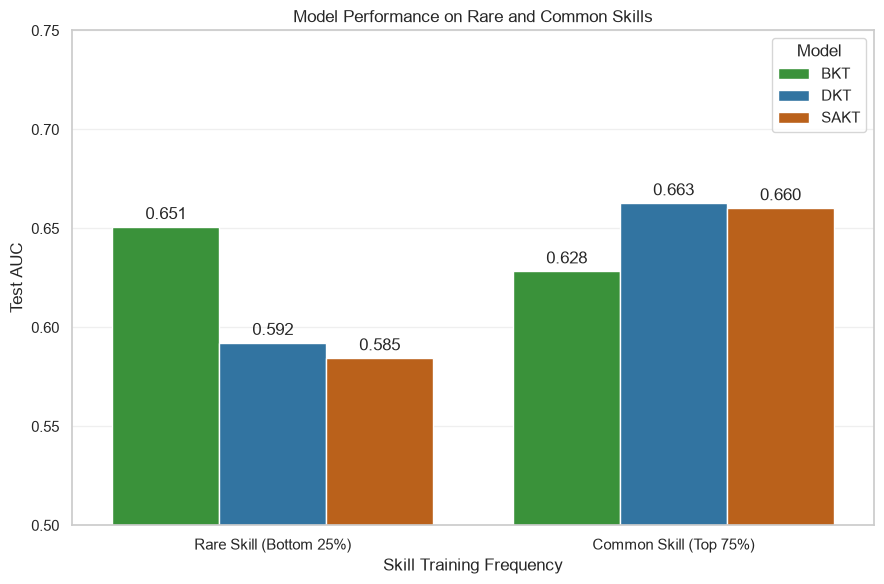

Figure saved to: /Users/tolulopesoetan/Desktop/msc_kt_ednet/results/figures/performance_by_skill_frequency.png


In [62]:
fig, ax = plt.subplots(figsize=(9, 6))

sns.barplot(
    data=skill_frequency_results_df,
    x="Skill Frequency Group",
    y="Test AUC",
    hue="Model",
    palette=["#2CA02C", "#1F77B4", "#D55E00"],
    ax=ax,
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3,
    )

maximum_auc = skill_frequency_results_df[
    "Test AUC"
].max()

ax.set_ylim(0.50, max(0.75, maximum_auc + 0.05))
ax.set_title(
    "Model Performance on Rare and Common Skills"
)
ax.set_xlabel("Skill Training Frequency")
ax.set_ylabel("Test AUC")
ax.legend(title="Model")
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

sparsity_figure_path = (
    FIGURES_DIR / "performance_by_skill_frequency.png"
)

fig.savefig(
    sparsity_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(f"Figure saved to: {sparsity_figure_path}")


## Probability Calibration

Discrimination metrics such as AUC do not establish whether predicted probabilities are reliable. Calibration is assessed using Expected Calibration Error, Brier score, and reliability diagrams. Lower values indicate better calibration for both error metrics.


In [63]:
def calculate_expected_calibration_error(
    y_true,
    y_probability,
    number_of_bins=10,
):
    y_true = np.asarray(y_true)
    y_probability = np.asarray(y_probability)

    bin_edges = np.linspace(
        0.0,
        1.0,
        number_of_bins + 1,
    )

    bin_indices = np.digitize(
        y_probability,
        bin_edges[1:-1],
        right=True,
    )

    calibration_error = 0.0

    for bin_index in range(number_of_bins):
        observations = bin_indices == bin_index

        if not np.any(observations):
            continue

        observed_accuracy = y_true[observations].mean()
        mean_confidence = y_probability[observations].mean()
        bin_weight = observations.mean()

        calibration_error += (
            bin_weight
            * abs(observed_accuracy - mean_confidence)
        )

    return calibration_error


In [64]:
calibration_inputs = {
    "BKT": (
        bkt_master_df["correct"].to_numpy(),
        bkt_master_df["correct_predictions"].to_numpy(),
    ),
    "DKT": (
        dl_master_df["true_target"].to_numpy(),
        dl_master_df["DKT_probability"].to_numpy(),
    ),
    "SAKT": (
        dl_master_df["true_target"].to_numpy(),
        dl_master_df["SAKT_probability"].to_numpy(),
    ),
}

calibration_results = []

for model_name, (
    true_values,
    probabilities,
) in calibration_inputs.items():
    calibration_results.append({
        "Model": model_name,
        "Expected Calibration Error": (
            calculate_expected_calibration_error(
                true_values,
                probabilities,
                number_of_bins=10,
            )
        ),
        "Brier Score": brier_score_loss(
            true_values,
            probabilities,
        ),
    })

calibration_results_df = pd.DataFrame(
    calibration_results
)

display(
    calibration_results_df.round({
        "Expected Calibration Error": 5,
        "Brier Score": 5,
    })
)

calibration_results_df.to_csv(
    TABLES_DIR / "model_calibration_metrics.csv",
    index=False,
)


,Model,Expected Calibration Error,Brier Score
0,BKT,0.00584,0.21534
1,DKT,0.00728,0.22265
2,SAKT,0.00361,0.22321


In [65]:
calibration_curve_records = []

for model_name, (
    true_values,
    probabilities,
) in calibration_inputs.items():
    observed_fraction, mean_prediction = calibration_curve(
        true_values,
        probabilities,
        n_bins=10,
        strategy="uniform",
    )

    for bin_number, (
        observed_value,
        predicted_value,
    ) in enumerate(
        zip(observed_fraction, mean_prediction),
        start=1,
    ):
        calibration_curve_records.append({
            "Model": model_name,
            "Bin": bin_number,
            "Mean Predicted Probability": predicted_value,
            "Observed Correctness Rate": observed_value,
        })

calibration_curve_df = pd.DataFrame(
    calibration_curve_records
)

calibration_curve_df.to_csv(
    TABLES_DIR / "calibration_curve_values.csv",
    index=False,
)

display(calibration_curve_df.round(5))


,Model,Bin,Mean Predicted Probability,Observed Correctness Rate
0,BKT,1,0.25200,0.25021
1,BKT,2,0.36584,0.35429
2,BKT,3,0.46316,0.44954
3,BKT,4,0.55983,0.55781
4,BKT,5,0.65114,0.64631
5,BKT,6,0.74997,0.74258
6,BKT,7,0.82845,0.82019
7,BKT,8,0.90922,0.88235
8,DKT,1,0.17275,0.16706
9,DKT,2,0.25288,0.26369


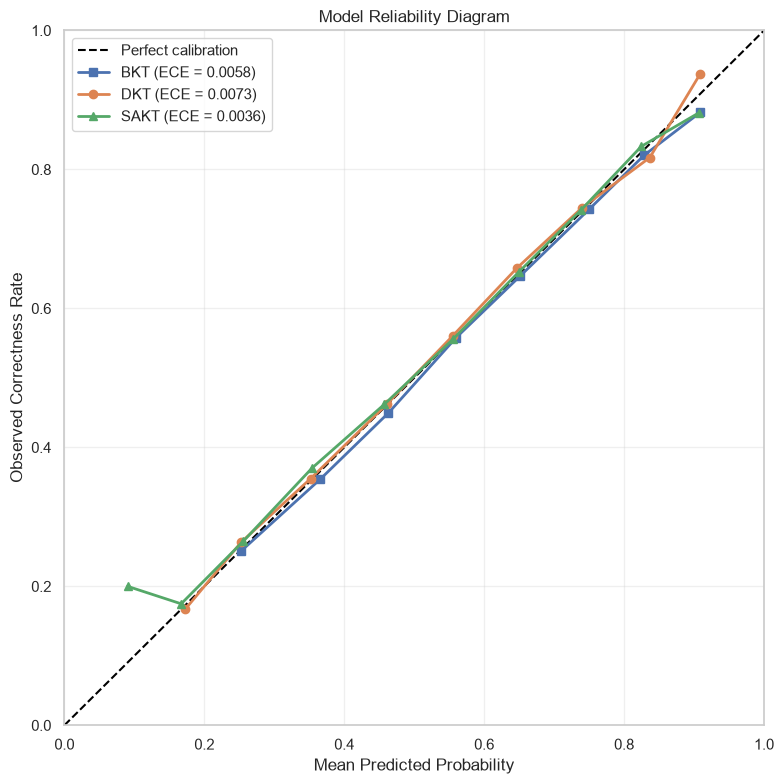

Figure saved to: /Users/tolulopesoetan/Desktop/msc_kt_ednet/results/figures/model_reliability_diagram.png


In [66]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    linewidth=1.5,
    label="Perfect calibration",
)

model_markers = {
    "BKT": "s",
    "DKT": "o",
    "SAKT": "^",
}

for model_name in model_markers:
    model_curve = calibration_curve_df[
        calibration_curve_df["Model"] == model_name
    ]

    model_ece = calibration_results_df.loc[
        calibration_results_df["Model"] == model_name,
        "Expected Calibration Error",
    ].iloc[0]

    ax.plot(
        model_curve["Mean Predicted Probability"],
        model_curve["Observed Correctness Rate"],
        marker=model_markers[model_name],
        linewidth=2,
        label=f"{model_name} (ECE = {model_ece:.4f})",
    )

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title("Model Reliability Diagram")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Observed Correctness Rate")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)

fig.tight_layout()

calibration_figure_path = (
    FIGURES_DIR / "model_reliability_diagram.png"
)

fig.savefig(
    calibration_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(f"Figure saved to: {calibration_figure_path}")


## Conclusion

This notebook establishes student-separated BKT, DKT, and causal SAKT benchmarks and evaluates their behaviour across learner-history length, skill frequency, sequence length, and probability calibration. The temporal-mask diagnostic demonstrates why causal masking is necessary when evaluating attention-based knowledge tracing models.
